# MILPÍN — EDA de verificación de KPIs Power BI

**Propósito:** confirmar que los valores que debería mostrar Power BI son correctos
antes de depurar medidas DAX. Si el número en Python coincide con el número en PBI,
el problema es la medida DAX. Si no coincide, el problema es el dato.

**KPIs auditados:**
| KPI | Fórmula | Valor esperado |
|---|---|---|
| Consumo m³/ha/ciclo (media) | SUM(volumen_m3_ha) por par (parcela,ciclo) → AVERAGE | ~7,780 m³/ha |
| Bajo meta 6,000 | % pares con consumo_ciclo ≤ 6,000 | ~18% |
| Bajo baseline 8,000 | % pares con consumo_ciclo ≤ 8,000 | ~49% |
| Tasa adopción recomendaciones | % `aceptada` == 'aceptada' | ~55% |
| Mix sistemas de riego | % eventos por sistema | gravedad ~64% |

**Fuente de datos:** `data/synthetic/` — CSVs generados por `tools/generar_datos_sinteticos.py` (seed=42)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MILPÍN — Auto-guardado en ML/images/
# Generado por ML/patch_notebooks.py — NO editar manualmente.
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
import sys as _sys
import re  as _re
import atexit as _atexit

# ── Directorio de salida ─────────────────────────────────────────────────────
_here = Path().resolve()
IMAGES_DIR = (
    _here.parent / "images"
    if _here.name == "experiments"
    else _here / "ML" / "images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Parche matplotlib: auto-save en plt.show() + redirigir plt.savefig ───────
import matplotlib.pyplot   as _plt
import matplotlib.figure   as _mpl_fig

_saved_fig_ids  = set()
_auto_fig_count = [0]
_orig_plt_show    = _plt.show
_orig_plt_savefig = _plt.savefig
_orig_fig_savefig = _mpl_fig.Figure.savefig

def _auto_fname(fig, n):
    title = (fig._suptitle.get_text() if fig._suptitle else "") or next(
        (ax.get_title() for ax in fig.get_axes() if ax.get_title()), "")
    stem = _re.sub(r"[^\w\-]", "_", title)[:50].strip("_").lower() if title else f"figura_{n:03d}"
    return f"{stem}.png"

def _patched_plt_savefig(fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    fig  = _plt.gcf()
    _orig_fig_savefig(fig, dest, *a, **kw)  # llama directo para evitar doble-parche
    _saved_fig_ids.add(id(fig))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_fig_savefig(self, fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    _orig_fig_savefig(self, dest, *a, **kw)
    _saved_fig_ids.add(id(self))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_plt_show(*a, **kw):
    fig = _plt.gcf()
    if fig.get_axes() and id(fig) not in _saved_fig_ids:
        _auto_fig_count[0] += 1
        fname = _auto_fname(fig, _auto_fig_count[0])
        _orig_fig_savefig(fig, IMAGES_DIR / fname, dpi=150, bbox_inches="tight")
        print(f"  ✓ [auto-imagen] {fname}")
    _saved_fig_ids.discard(id(fig))
    _orig_plt_show(*a, **kw)

_plt.show               = _patched_plt_show
_plt.savefig            = _patched_plt_savefig
_mpl_fig.Figure.savefig = _patched_fig_savefig

# ── Parche pandas: auto-save DataFrames al mostrarse en Jupyter ─────────────
_df_count = [0]
try:
    import pandas as _pd
    _orig_df_repr_html = _pd.DataFrame._repr_html_

    def _patched_df_repr_html(self):
        _df_count[0] += 1
        stem = f"tabla_{_df_count[0]:03d}"
        self.to_csv(IMAGES_DIR / f"{stem}.csv", index=True, encoding="utf-8-sig")
        self.to_html(IMAGES_DIR / f"{stem}.html")
        print(f"  ✓ [tabla] {stem}.csv  ({len(self)} filas × {len(self.columns)} cols)")
        return _orig_df_repr_html(self)

    _pd.DataFrame._repr_html_ = _patched_df_repr_html
except Exception as _pd_err:
    print(f"  ! pandas hook: {_pd_err}")

# ── Capturar stdout → IMAGES_DIR/output_log.txt ──────────────────────────────
_log_path = IMAGES_DIR / "output_log.txt"
_log_file = open(_log_path, "w", encoding="utf-8")

class _Tee:
    def __init__(self, real, log):
        self._real = real
        self._log  = log
    def write(self, s):
        self._real.write(s)
        self._log.write(s)
    def flush(self):
        self._real.flush()
        self._log.flush()
    def __getattr__(self, attr):
        return getattr(self._real, attr)

_sys.stdout = _Tee(_sys.__stdout__, _log_file)
_atexit.register(lambda: (_log_file.flush(), _log_file.close()))

print(f"✓ IMAGES_DIR  → {IMAGES_DIR}")
print(f"✓ matplotlib  → auto-save en show() + redirigir savefig()")
print(f"✓ pandas      → auto-save DataFrames (CSV + HTML)")
print(f"✓ stdout      → {_log_path.name}")


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

DATA = Path('..') / 'data' / 'synthetic'

hr  = pd.read_csv(DATA / 'historial_riego.csv', parse_dates=['fecha_riego'])
par = pd.read_csv(DATA / 'parcelas.csv')
rec = pd.read_csv(DATA / 'recomendaciones.csv')
cos = pd.read_csv(DATA / 'costos_ciclo.csv')
ano = pd.read_csv(DATA / 'anomalias_labels.csv') if (DATA / 'anomalias_labels.csv').exists() else pd.DataFrame()

print(f'historial_riego : {len(hr):>6,} filas  |  columnas: {list(hr.columns)}')
print(f'parcelas        : {len(par):>6,} filas')
print(f'recomendaciones : {len(rec):>6,} filas')
print(f'costos_ciclo    : {len(cos):>6,} filas')
print(f'anomalias_labels: {len(ano):>6,} filas')

historial_riego : 13,427 filas  |  columnas: ['id_riego', 'id_parcela', 'ciclo_agricola', 'id_recomendacion', 'fecha_riego', 'volumen_m3_ha', 'lamina_mm', 'duracion_horas', 'metodo_riego', 'origen_decision', 'costo_energia_mxn', 'ciclo_vol_target_m3_ha', 'observaciones', 'created_at']
parcelas        :     80 filas
recomendaciones : 20,800 filas
costos_ciclo    :    800 filas
anomalias_labels:    146 filas


## 1. Consumo m³/ha/ciclo — el KPI central

In [2]:
# Agregar por (parcela, ciclo) — esto es lo que debe hacer Power BI internamente
ciclo_agg = (
    hr.groupby(['id_parcela', 'ciclo_agricola'])
      .agg(
          consumo_m3_ha   = ('volumen_m3_ha', 'sum'),
          n_eventos       = ('id_riego', 'count'),
          vol_evento_mean = ('volumen_m3_ha', 'mean'),
          costo_total_mxn = ('costo_energia_mxn', 'sum'),
      )
      .reset_index()
)

# Unir con parcelas para tener sistema_riego y area_ha
ciclo_agg = ciclo_agg.merge(par[['id_parcela', 'area_ha', 'sistema_riego']], on='id_parcela')

BASELINE = 8_000
META     = 6_000

media_global = ciclo_agg['consumo_m3_ha'].mean()
bajo_meta    = (ciclo_agg['consumo_m3_ha'] <= META).mean() * 100
bajo_base    = (ciclo_agg['consumo_m3_ha'] <= BASELINE).mean() * 100

print('━' * 52)
print(f'  Pares (parcela × ciclo) analizados : {len(ciclo_agg):>5}')
print(f'  Consumo medio global    m³/ha/ciclo: {media_global:>8,.0f}')
print(f'  Baseline DR-041         m³/ha/ciclo: {BASELINE:>8,}  ← referencia CONAGUA')
print(f'  Meta MILPÍN             m³/ha/ciclo: {META:>8,}  ← objetivo -25%')
print(f'  % ciclos bajo meta 6,000            : {bajo_meta:>7.1f}%')
print(f'  % ciclos bajo baseline 8,000        : {bajo_base:>7.1f}%')
print('━' * 52)
print('\nEstadísticas detalladas:')
print(ciclo_agg['consumo_m3_ha'].describe().rename({
    'count':'n_pares','mean':'media','std':'desv_std',
    'min':'min','25%':'p25','50%':'mediana','75%':'p75','max':'max'
}).to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pares (parcela × ciclo) analizados :   960
  Consumo medio global    m³/ha/ciclo:    8,126
  Baseline DR-041         m³/ha/ciclo:    8,000  ← referencia CONAGUA
  Meta MILPÍN             m³/ha/ciclo:    6,000  ← objetivo -25%
  % ciclos bajo meta 6,000            :    18.4%
  % ciclos bajo baseline 8,000        :    49.2%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Estadísticas detalladas:
n_pares       960.000000
media        8125.644052
desv_std     2308.020461
min          3671.930000
p25          6463.790000
mediana      8034.895000
p75          9364.122500
max         19840.770000


C:\Users\madri\AppData\Local\Temp\ipykernel_724\3435637638.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_box, labels=labels_box, patch_artist=True,


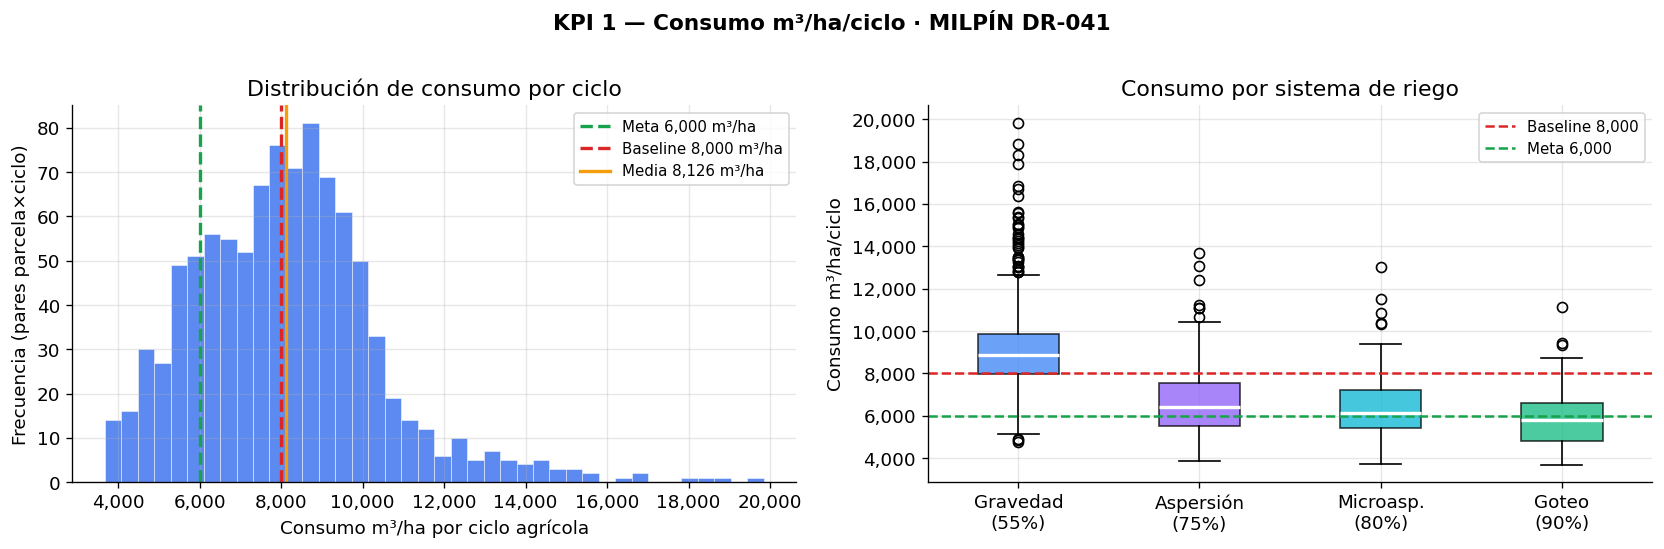

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ── Panel A: histograma de consumo por ciclo ──────────────────────────────
ax = axes[0]
ax.hist(ciclo_agg['consumo_m3_ha'], bins=40, color='#2563EB', alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axvline(META,     color='#16A34A', lw=2, ls='--', label=f'Meta 6,000 m³/ha')
ax.axvline(BASELINE, color='#DC2626', lw=2, ls='--', label=f'Baseline 8,000 m³/ha')
ax.axvline(media_global, color='#F59E0B', lw=2, ls='-', label=f'Media {media_global:,.0f} m³/ha')
ax.set_xlabel('Consumo m³/ha por ciclo agrícola')
ax.set_ylabel('Frecuencia (pares parcela×ciclo)')
ax.set_title('Distribución de consumo por ciclo')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)

# ── Panel B: box por sistema de riego ────────────────────────────────────
ax2 = axes[1]
sistemas_orden = ['gravedad', 'aspersion', 'microaspersion', 'goteo']
data_box = [ciclo_agg.loc[ciclo_agg['sistema_riego'] == s, 'consumo_m3_ha'].values
            for s in sistemas_orden]
labels_box = ['Gravedad\n(55%)', 'Aspersión\n(75%)', 'Microasp.\n(80%)', 'Goteo\n(90%)']
bp = ax2.boxplot(data_box, labels=labels_box, patch_artist=True,
                 medianprops={'color': 'white', 'linewidth': 2})
colors = ['#3B82F6', '#8B5CF6', '#06B6D4', '#10B981']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.axhline(BASELINE, color='#DC2626', lw=1.5, ls='--', label='Baseline 8,000')
ax2.axhline(META, color='#16A34A', lw=1.5, ls='--', label='Meta 6,000')
ax2.set_ylabel('Consumo m³/ha/ciclo')
ax2.set_title('Consumo por sistema de riego')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:,.0f}'))
ax2.legend(fontsize=9)

fig.suptitle('KPI 1 — Consumo m³/ha/ciclo · MILPÍN DR-041', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. KPI por sistema de riego — tabla de referencia Power BI

In [4]:
tabla_sistema = (
    ciclo_agg.groupby('sistema_riego')
    .agg(
        n_pares         = ('consumo_m3_ha', 'count'),
        consumo_media   = ('consumo_m3_ha', 'mean'),
        consumo_mediana = ('consumo_m3_ha', 'median'),
        consumo_p75     = ('consumo_m3_ha', lambda x: x.quantile(0.75)),
        bajo_meta_pct   = ('consumo_m3_ha', lambda x: (x <= META).mean() * 100),
        bajo_base_pct   = ('consumo_m3_ha', lambda x: (x <= BASELINE).mean() * 100),
    )
)
tabla_sistema['ahorro_vs_gravedad_pct'] = (
    1 - tabla_sistema['consumo_media'] /
        tabla_sistema.loc['gravedad', 'consumo_media']
) * 100

print('Consumo m³/ha/ciclo por sistema de riego')
print('━' * 80)
display_cols = ['n_pares','consumo_media','consumo_mediana','bajo_meta_pct','bajo_base_pct','ahorro_vs_gravedad_pct']
fmt = {
    'consumo_media':          lambda x: f'{x:,.0f}',
    'consumo_mediana':        lambda x: f'{x:,.0f}',
    'bajo_meta_pct':          lambda x: f'{x:.1f}%',
    'bajo_base_pct':          lambda x: f'{x:.1f}%',
    'ahorro_vs_gravedad_pct': lambda x: f'{x:+.1f}%',
}
print(tabla_sistema[display_cols].to_string(formatters=fmt))
print()
print('→ Reducción goteo vs gravedad esperada por literatura: 25-40% (CIMMYT 2020)')
print(f'→ Reducción simulada: {tabla_sistema.loc["goteo", "ahorro_vs_gravedad_pct"]:+.1f}%  ✓ dentro del rango')

Consumo m³/ha/ciclo por sistema de riego
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                n_pares consumo_media consumo_mediana bajo_meta_pct bajo_base_pct ahorro_vs_gravedad_pct
sistema_riego                                                                                           
aspersion           168         6,719           6,407         38.7%         81.5%                 +26.8%
goteo                60         5,954           5,815         55.0%         90.0%                 +35.1%
gravedad            588         9,180           8,861          1.9%         26.0%                  +0.0%
microaspersion      144         6,367           6,121         47.2%         88.9%                 +30.6%

→ Reducción goteo vs gravedad esperada por literatura: 25-40% (CIMMYT 2020)
→ Reducción simulada: +35.1%  ✓ dentro del rango


## 3. Tendencia temporal — consumo promedio por ciclo agrícola

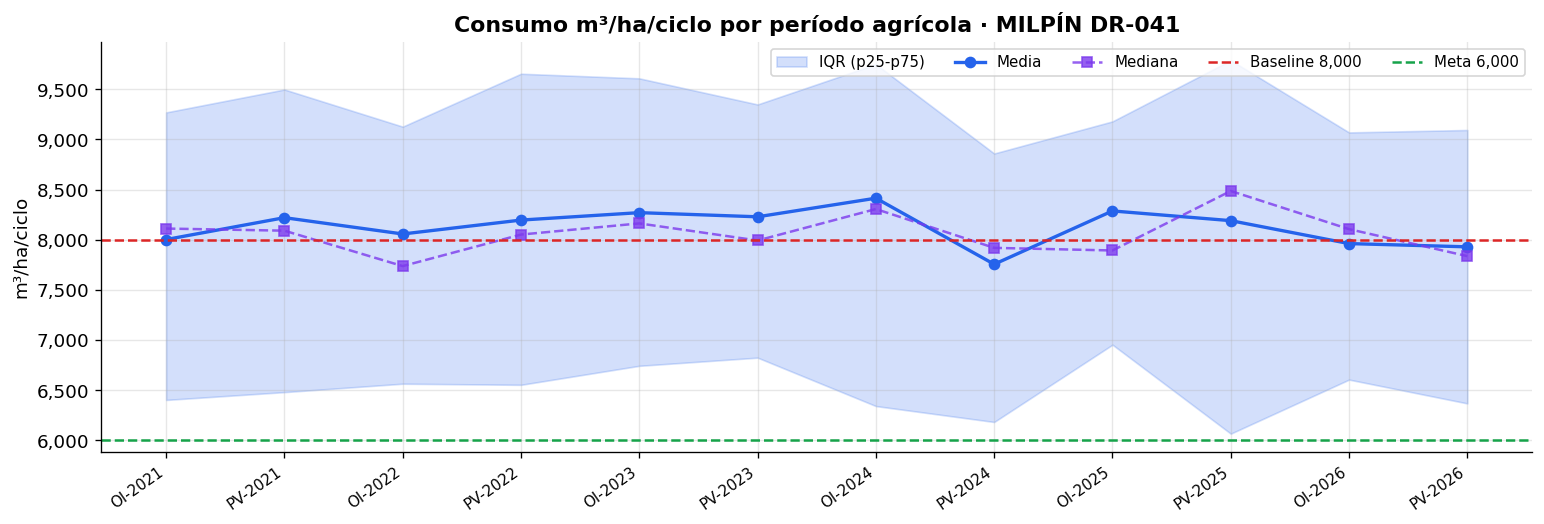

Nota: variación entre ciclos OI y PV es esperada (diferente ETo estacional).
Los datos sintéticos no modelan estacionalidad en ETo, solo ruido Normal truncado.


In [5]:
CICLOS_ORDEN = [
    'OI-2021','PV-2021','OI-2022','PV-2022','OI-2023',
    'PV-2023','OI-2024','PV-2024','OI-2025','PV-2025','OI-2026','PV-2026'
]

tendencia = (
    ciclo_agg.groupby('ciclo_agricola')
    ['consumo_m3_ha']
    .agg(['mean', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    .rename(columns={'mean': 'media', 'median': 'mediana',
                     '<lambda_0>': 'p25', '<lambda_1>': 'p75'})
    .reindex(CICLOS_ORDEN)
)

fig, ax = plt.subplots(figsize=(13, 4.5))
x = range(len(tendencia))
ax.fill_between(x, tendencia['p25'], tendencia['p75'], alpha=0.2, color='#2563EB', label='IQR (p25-p75)')
ax.plot(x, tendencia['media'],   'o-', color='#2563EB', lw=2, label='Media')
ax.plot(x, tendencia['mediana'], 's--', color='#7C3AED', lw=1.5, alpha=0.8, label='Mediana')
ax.axhline(BASELINE, color='#DC2626', lw=1.5, ls='--', label='Baseline 8,000')
ax.axhline(META,     color='#16A34A', lw=1.5, ls='--', label='Meta 6,000')
ax.set_xticks(list(x))
ax.set_xticklabels(CICLOS_ORDEN, rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:,.0f}'))
ax.set_ylabel('m³/ha/ciclo')
ax.set_title('Consumo m³/ha/ciclo por período agrícola · MILPÍN DR-041', fontweight='bold')
ax.legend(ncol=5, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print('Nota: variación entre ciclos OI y PV es esperada (diferente ETo estacional).')
print('Los datos sintéticos no modelan estacionalidad en ETo, solo ruido Normal truncado.')

## 4. Volumen por evento vs volumen por ciclo — la confusión origen del problema DAX

In [6]:
print('NIVEL EVENTO (una fila de historial_riego):')
desc_ev = hr['volumen_m3_ha'].describe()
desc_ev.index = ['n_eventos','media','desv','min','p25','mediana','p75','max']
print(desc_ev.apply(lambda x: f'{x:,.2f}').to_string())

print()
print('NIVEL CICLO (SUM por parcela × ciclo — el KPI real):')
desc_cic = ciclo_agg['consumo_m3_ha'].describe()
desc_cic.index = ['n_pares','media','desv','min','p25','mediana','p75','max']
print(desc_cic.apply(lambda x: f'{x:,.2f}').to_string())

print()
print('━' * 56)
print(f'  Media evento  : {hr["volumen_m3_ha"].mean():>9,.2f} m³/ha  ← lo que AVERAGE(volumen_m3_ha) devuelve')
print(f'  Media ciclo   : {ciclo_agg["consumo_m3_ha"].mean():>9,.2f} m³/ha  ← el KPI correcto vs baseline')
print(f'  Factor promedio de eventos/ciclo: {ciclo_agg["n_eventos"].mean():.1f}')
print('━' * 56)
print('  En Power BI: usar SUM(volumen_m3_ha) filtrado por ciclo, NO AVERAGE de eventos.')

NIVEL EVENTO (una fila de historial_riego):
n_eventos    13,427.00
media           580.97
desv            540.67
min               3.85
p25             220.62
mediana         420.76
p75             764.04
max           8,350.78

NIVEL CICLO (SUM por parcela × ciclo — el KPI real):
n_pares       960.00
media       8,125.64
desv        2,308.02
min         3,671.93
p25         6,463.79
mediana     8,034.89
p75         9,364.12
max        19,840.77

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Media evento  :    580.97 m³/ha  ← lo que AVERAGE(volumen_m3_ha) devuelve
  Media ciclo   :  8,125.64 m³/ha  ← el KPI correcto vs baseline
  Factor promedio de eventos/ciclo: 14.0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  En Power BI: usar SUM(volumen_m3_ha) filtrado por ciclo, NO AVERAGE de eventos.


## 5. Mix de sistemas de riego — verificar vs distribución diseñada (65/8/15/12%)

Distribución de sistemas de riego:
                diseño_%  parcelas_%  eventos_%
aspersion             15        17.5       21.8
goteo                  8         6.2       10.1
gravedad              65        61.3       49.5
microaspersion        12        15.0       18.6


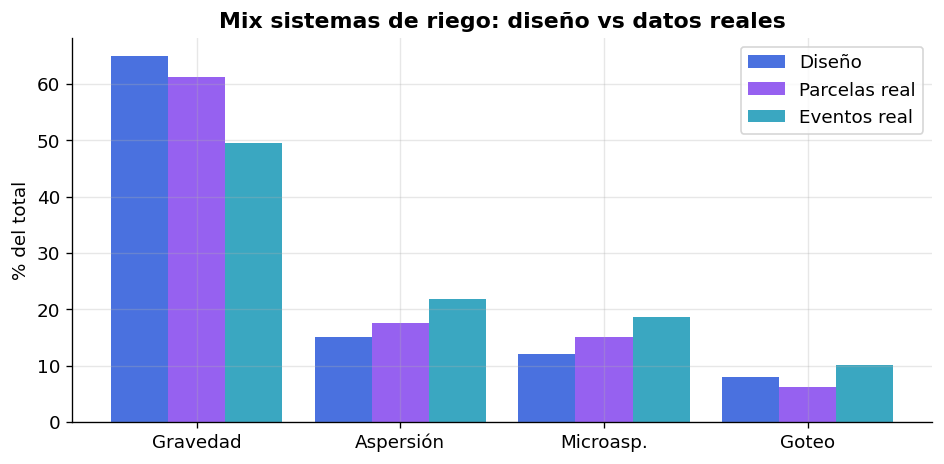

In [7]:
# Distribución a nivel de PARCELA (no evento)
mix_par = par['sistema_riego'].value_counts(normalize=True) * 100
mix_ev  = hr['metodo_riego'].value_counts(normalize=True) * 100

diseño = pd.Series({'gravedad': 65, 'goteo': 8, 'aspersion': 15, 'microaspersion': 12},
                   name='diseño_%')

comparacion = pd.DataFrame({
    'diseño_%':    diseño,
    'parcelas_%':  mix_par.round(1),
    'eventos_%':   mix_ev.round(1),
})
print('Distribución de sistemas de riego:')
print(comparacion.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
sistemas = ['gravedad', 'aspersion', 'microaspersion', 'goteo']
x_pos = np.arange(len(sistemas))
w = 0.28
bar_colors = ['#1D4ED8', '#7C3AED', '#0891B2']
for i, (col, label) in enumerate([('diseño_%','Diseño'), ('parcelas_%','Parcelas real'), ('eventos_%','Eventos real')]):
    vals = [comparacion.loc[s, col] if s in comparacion.index else 0 for s in sistemas]
    ax.bar(x_pos + (i - 1) * w, vals, w, label=label, color=bar_colors[i], alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Gravedad', 'Aspersión', 'Microasp.', 'Goteo'])
ax.set_ylabel('% del total')
ax.set_title('Mix sistemas de riego: diseño vs datos reales', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Tasa de adopción de recomendaciones

Estado de recomendaciones:
  aceptada    : 11,394  (54.8%)
  pendiente   :  4,258  (20.5%)
  modificada  :  3,044  (14.6%)
  ignorada    :  2,104  (10.1%)

  → Tasa adopción (aceptada) : 54.8%  |  diseño objetivo: ~55%


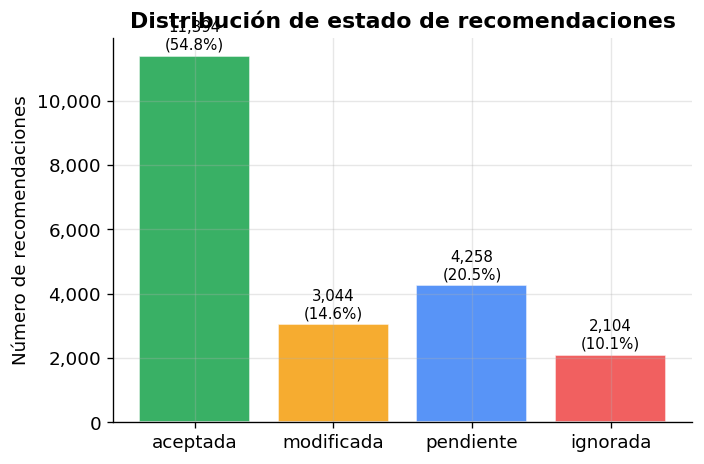

In [8]:
adopcion = rec['aceptada'].value_counts()
adopcion_pct = adopcion / len(rec) * 100

print('Estado de recomendaciones:')
for estado in ['aceptada', 'pendiente', 'modificada', 'ignorada']:
    n   = adopcion.get(estado, 0)
    pct = adopcion_pct.get(estado, 0.0)
    print(f'  {estado:<12}: {n:>6,}  ({pct:.1f}%)')

tasa = adopcion_pct.get('aceptada', 0)
print(f'\n  → Tasa adopción (aceptada) : {tasa:.1f}%  |  diseño objetivo: ~55%')

fig, ax = plt.subplots(figsize=(6, 4))
colores_estado = {'aceptada': '#16A34A', 'modificada': '#F59E0B', 'pendiente': '#3B82F6', 'ignorada': '#EF4444'}
estados = [s for s in ['aceptada', 'modificada', 'pendiente', 'ignorada'] if s in adopcion.index]
vals = [adopcion[s] for s in estados]
colores = [colores_estado[s] for s in estados]
ax.bar(estados, vals, color=colores, alpha=0.85, edgecolor='white')
for i, (s, v) in enumerate(zip(estados, vals)):
    ax.text(i, v + 200, f'{v:,}\n({adopcion_pct[s]:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Número de recomendaciones')
ax.set_title('Distribución de estado de recomendaciones', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:,.0f}'))
plt.tight_layout()
plt.show()

## 7. Costo de energía — verificación vs tarifa CFE 9-CU ($1.68 MXN/m³)

In [9]:
TARIFA = 1.68

# Tarifa implícita por evento: costo / (vol_m3_ha * area_ha)
hr_par = hr.merge(par[['id_parcela', 'area_ha']], on='id_parcela')
hr_par['vol_total_m3'] = hr_par['volumen_m3_ha'] * hr_par['area_ha']
hr_par['tarifa_implicita'] = hr_par['costo_energia_mxn'] / hr_par['vol_total_m3']

desc_tar = hr_par['tarifa_implicita'].describe()
desc_tar.index = ['n','media','desv','min','p25','mediana','p75','max']
print('Tarifa implícita por evento (MXN/m³):')
print(desc_tar.apply(lambda x: f'{x:.4f}').to_string())
print(f'\nTarifa de diseño: {TARIFA} MXN/m³  ±10% ruido → rango esperado [{TARIFA*0.85:.3f}, {TARIFA*1.15:.3f}]')

# Costo total de ciclo por sistema
costo_sistema = (
    ciclo_agg.groupby('sistema_riego')
    .agg(
        costo_mxn_ciclo_media = ('costo_total_mxn', 'mean'),
        vol_m3_ha_media       = ('consumo_m3_ha', 'mean'),
    )
)
print('\nCosto medio por ciclo por sistema (MXN totales — función del area_ha de cada parcela):')
fmt2 = {'costo_mxn_ciclo_media': lambda x: f'{x:,.0f}', 'vol_m3_ha_media': lambda x: f'{x:,.0f}'}
print(costo_sistema.to_string(formatters=fmt2))

Tarifa implícita por evento (MXN/m³):
n          13427.0000
media          1.6787
desv           0.1456
min            1.4281
p25            1.5526
mediana        1.6787
p75            1.8043
max            1.9320

Tarifa de diseño: 1.68 MXN/m³  ±10% ruido → rango esperado [1.428, 1.932]

Costo medio por ciclo por sistema (MXN totales — función del area_ha de cada parcela):
               costo_mxn_ciclo_media vol_m3_ha_media
sistema_riego                                       
aspersion                    163,289           6,719
goteo                        101,940           5,954
gravedad                     206,257           9,180
microaspersion               146,074           6,367


## 8. Anomalías inyectadas — impacto en el KPI de consumo

Anomalías etiquetadas: 146 pares (parcela × ciclo)
tipo_anomalia
AGRICULTOR_INEFICIENTE    80
SOBRE_RIEGO               38
GAP_FALLA_EQUIPO          28

Consumo medio ciclos normales  :     7,746 m³/ha
Consumo medio ciclos anómalos  :    10,241 m³/ha
Sobreconsumo anomalías         : +32.2%


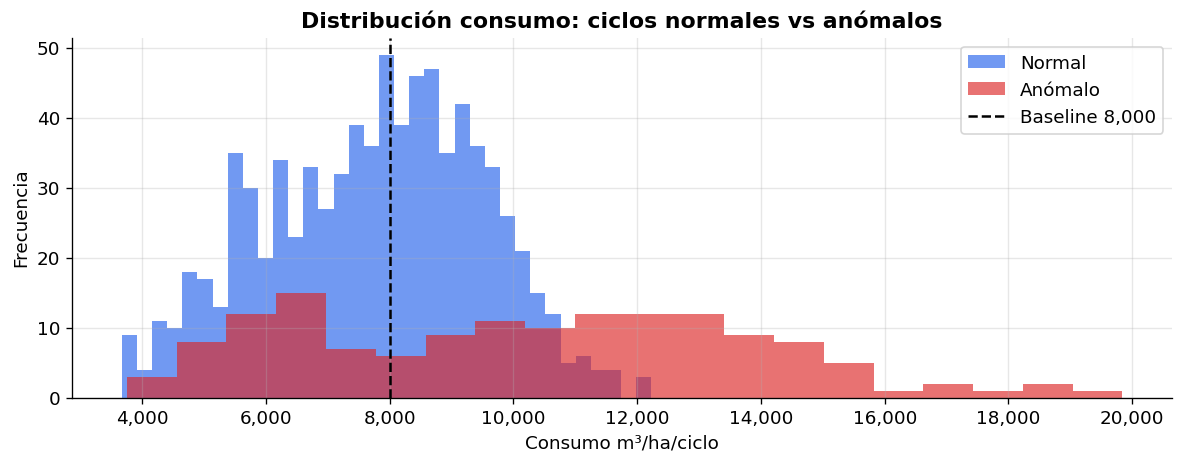

In [10]:
if ano.empty:
    print('anomalias_labels.csv no encontrado. Regener con --anomalias para ver este análisis.')
else:
    print(f'Anomalías etiquetadas: {len(ano)} pares (parcela × ciclo)')
    print(ano['tipo_anomalia'].value_counts().to_string())
    print()

    # Marcar ciclos anómalos
    ano_keys = set(zip(ano['id_parcela'], ano['ciclo_agricola']))
    ciclo_agg['es_anomalia'] = [
        (pid, cic) in ano_keys
        for pid, cic in zip(ciclo_agg['id_parcela'], ciclo_agg['ciclo_agricola'])
    ]

    normal = ciclo_agg.loc[~ciclo_agg['es_anomalia'], 'consumo_m3_ha']
    anomalo = ciclo_agg.loc[ ciclo_agg['es_anomalia'], 'consumo_m3_ha']

    print(f'Consumo medio ciclos normales  : {normal.mean():>9,.0f} m³/ha')
    print(f'Consumo medio ciclos anómalos  : {anomalo.mean():>9,.0f} m³/ha')
    print(f'Sobreconsumo anomalías         : +{(anomalo.mean()/normal.mean()-1)*100:.1f}%')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(normal,  bins=35, alpha=0.65, color='#2563EB', label='Normal')
    ax.hist(anomalo, bins=20, alpha=0.65, color='#DC2626', label='Anómalo')
    ax.axvline(BASELINE, color='black', lw=1.5, ls='--', label='Baseline 8,000')
    ax.set_xlabel('Consumo m³/ha/ciclo')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Distribución consumo: ciclos normales vs anómalos', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Tabla resumen — valores esperados en Power BI

In [11]:
ultimo_ciclo = max(CICLOS_ORDEN, key=lambda c: CICLOS_ORDEN.index(c))
ciclos_ultimo = ciclo_agg[ciclo_agg['ciclo_agricola'] == ultimo_ciclo]

consumo_ultimo = ciclos_ultimo['consumo_m3_ha'].mean()
ahorro_m3     = BASELINE - consumo_ultimo
ahorro_mxn    = ahorro_m3 * TARIFA
pct_ahorro    = ahorro_m3 / BASELINE * 100
tasa_adop     = adopcion_pct.get('aceptada', 0)

print('═' * 60)
print('  VALORES ESPERADOS EN POWER BI (ciclo más reciente)')
print('═' * 60)
print(f'  Ciclo de referencia        : {ultimo_ciclo}')
print(f'  Consumo_Ciclo_m3_ha        : {consumo_ultimo:>10,.0f} m³/ha')
print(f'  Linea_Base_m3_ha           : {BASELINE:>10,} m³/ha')
print(f'  Objetivo_m3_ha             : {META:>10,} m³/ha')
print(f'  Ahorro_m3_ha               : {ahorro_m3:>+10,.0f} m³/ha')
print(f'  Ahorro_Costo_MXN_ha        : {ahorro_mxn:>+10,.0f} MXN/ha')
print(f'  Pct_Ahorro                 : {pct_ahorro:>+9.1f}%')
print(f'  Tasa_Adopcion_Pct          : {tasa_adop:>9.1f}%')
print(f'  % Ciclos_Bajo_Meta_6000    : {bajo_meta:>9.1f}%')
print('═' * 60)
print()
if ahorro_m3 > 0:
    print(f'  ✓ Consumo por debajo del baseline — sistema funcionando')
else:
    print(f'  ✗ Consumo por encima del baseline para este ciclo')
print(f'  Nota: KPI real requiere conectar Power BI a ciclo específico via slicer.')

════════════════════════════════════════════════════════════
  VALORES ESPERADOS EN POWER BI (ciclo más reciente)
════════════════════════════════════════════════════════════
  Ciclo de referencia        : PV-2026
  Consumo_Ciclo_m3_ha        :      7,929 m³/ha
  Linea_Base_m3_ha           :      8,000 m³/ha
  Objetivo_m3_ha             :      6,000 m³/ha
  Ahorro_m3_ha               :        +71 m³/ha
  Ahorro_Costo_MXN_ha        :       +119 MXN/ha
  Pct_Ahorro                 :      +0.9%
  Tasa_Adopcion_Pct          :      54.8%
  % Ciclos_Bajo_Meta_6000    :      18.4%
════════════════════════════════════════════════════════════

  ✓ Consumo por debajo del baseline — sistema funcionando
  Nota: KPI real requiere conectar Power BI a ciclo específico via slicer.
